# Zomato Rating Predictor
## Notebook 3 — Modelling & SHAP Interpretability

**Objective:** Train three progressively stronger models to predict `Aggregate rating`, compare them rigorously, then use SHAP to explain *why* the best model makes the predictions it does.

**Input:** `zomato_clean.csv`  
**Output:** `xgb_model.pkl`, `feature_columns.pkl` (used by the Streamlit app)

---
## 0. Setup

In [1]:
# Install SHAP if not already available
!pip install shap --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.linear_model       import LinearRegression
from sklearn.ensemble           import RandomForestRegressor
from sklearn.preprocessing      import StandardScaler
from sklearn.pipeline           import Pipeline
from sklearn.metrics            import mean_squared_error, mean_absolute_error, r2_score
from xgboost                    import XGBRegressor
from google.colab               import drive

drive.mount('/content/drive')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE  = '/content/drive/MyDrive/Colab Notebooks/zomato-rating-predictor'
DATA  = f'{BASE}/data/zomato_clean.csv'
MODELS = f'{BASE}/models'

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

TEAL  = '#0F6E56'
CORAL = '#D85A30'
NAVY  = '#1B3A5C'
GOLD  = '#C8960C'
GREY  = '#888780'

print('Setup complete.')

Mounted at /content/drive
Setup complete.


---
## 1. Load & Split Data

In [3]:
df = pd.read_csv(DATA)
print(f'Shape: {df.shape}')
df.head()

Shape: (7403, 28)


,Average Cost for two,Has Table booking,Has Online delivery,Price range,Aggregate rating,Votes,cuisine_count,is_multi_cuisine,log_votes,cost_per_person,...,country_Qatar,country_Singapore,country_South Africa,country_Sri Lanka,country_Turkey,country_UAE,country_United Kingdom,country_United States,cuisine_freq_enc,city_freq_enc
0,1100,1,0,3,4.8,314,3,1,5.752573,550.0,...,False,False,False,False,False,False,False,False,0.001891,0.00027
1,1200,1,0,3,4.5,591,1,0,6.383507,600.0,...,False,False,False,False,False,False,False,False,0.009591,0.00027
2,4000,1,0,4,4.4,270,4,1,5.602119,2000.0,...,False,False,False,False,False,False,False,False,0.006484,0.00054
3,1500,0,0,4,4.9,365,2,1,5.902633,750.0,...,False,False,False,False,False,False,False,False,0.009591,0.00054
4,1500,1,0,4,4.8,229,2,1,5.438079,750.0,...,False,False,False,False,False,False,False,False,0.009591,0.00054


In [4]:
# ── Define features and target ─────────────────────────────────────────────
TARGET = 'Aggregate rating'

# Drop helper columns created only for EDA plotting
drop_for_model = ['price_label', 'country_label', 'cuisine_bucket']
drop_for_model = [c for c in drop_for_model if c in df.columns]

X = df.drop(columns=[TARGET] + drop_for_model)
y = df[TARGET]

# Save the exact feature column order — Streamlit app needs this
feature_columns = X.columns.tolist()

print(f'Features: {len(feature_columns)}')
print(f'Target:   {TARGET}')
print(f'X shape:  {X.shape}')
print(f'y shape:  {y.shape}')
print(f'y range:  {y.min():.1f} – {y.max():.1f}')

Features: 27
Target:   Aggregate rating
X shape:  (7403, 27)
y shape:  (7403,)
y range:  1.8 – 4.9


In [5]:
# ── Train / test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test:  {X_test.shape[0]:,} rows')

Train: 5,922 rows
Test:  1,481 rows


---
## 2. Evaluation Helper

A single function to score any model consistently — RMSE, MAE, and R².

In [6]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, return metrics dict, print results."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    r2   = r2_score(y_te, preds)

    # 5-fold CV on training set (RMSE)
    cv_scores = cross_val_score(
        model, X_tr, y_tr,
        scoring='neg_root_mean_squared_error', cv=5
    )
    cv_rmse = -cv_scores.mean()

    print(f'┌─ {name} ─')
    print(f'│  RMSE (test):     {rmse:.4f}')
    print(f'│  MAE  (test):     {mae:.4f}')
    print(f'│  R²   (test):     {r2:.4f}')
    print(f'│  CV RMSE (train): {cv_rmse:.4f} ± {-cv_scores.std():.4f}')
    print(f'└─────────────────────────────')

    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'CV RMSE': cv_rmse}

results = []

---
## 3. Model 1 — Linear Regression (Baseline)

Sets the performance floor. If our complex models can't beat this meaningfully, something is wrong with the features.

In [7]:
# Linear Regression benefits from scaled features
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

lr_metrics = evaluate(
    'Linear Regression',
    lr_pipeline, X_train, y_train, X_test, y_test
)
results.append(lr_metrics)

┌─ Linear Regression ─
│  RMSE (test):     0.3698
│  MAE  (test):     0.2731
│  R²   (test):     0.5578
│  CV RMSE (train): 0.3804 ± -0.0191
└─────────────────────────────


---
## 4. Model 2 — Random Forest

A strong ensemble baseline. No scaling needed. Captures non-linear relationships.

In [8]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_metrics = evaluate(
    'Random Forest',
    rf, X_train, y_train, X_test, y_test
)
results.append(rf_metrics)

┌─ Random Forest ─
│  RMSE (test):     0.3395
│  MAE  (test):     0.2529
│  R²   (test):     0.6274
│  CV RMSE (train): 0.3562 ± -0.0140
└─────────────────────────────


---
## 5. Model 3 — XGBoost (Tuned)

Our primary model. We run `RandomizedSearchCV` over a broad grid, then refit the best estimator on the full training set.

In [9]:
# ── 5a. Hyperparameter search ──────────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 200, 300, 400],
    'max_depth':         [3, 4, 5, 6, 8],
    'learning_rate':     [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
    'min_child_weight':  [1, 3, 5],
    'gamma':             [0, 0.1, 0.2],
}

xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

search = RandomizedSearchCV(
    xgb_base, param_grid,
    n_iter=60,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f'Best CV RMSE: {-search.best_score_:.4f}')
print(f'Best params:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV RMSE: 0.3491
Best params:
  subsample: 0.8
  n_estimators: 400
  min_child_weight: 3
  max_depth: 5
  learning_rate: 0.1
  gamma: 0.2
  colsample_bytree: 0.7


In [10]:
# ── 5b. Evaluate best XGBoost ──────────────────────────────────────────────
xgb_best = search.best_estimator_

xgb_metrics = evaluate(
    'XGBoost (tuned)',
    xgb_best, X_train, y_train, X_test, y_test
)
results.append(xgb_metrics)

┌─ XGBoost (tuned) ─
│  RMSE (test):     0.3317
│  MAE  (test):     0.2479
│  R²   (test):     0.6442
│  CV RMSE (train): 0.3491 ± -0.0165
└─────────────────────────────


---
## 6. Model Comparison

In [11]:
results_df = pd.DataFrame(results).set_index('Model').round(4)
print('=== Model Comparison ===')
print(results_df.to_string())

=== Model Comparison ===
                     RMSE     MAE      R²  CV RMSE
Model                                             
Linear Regression  0.3698  0.2731  0.5578   0.3804
Random Forest      0.3395  0.2529  0.6274   0.3562
XGBoost (tuned)    0.3317  0.2479  0.6442   0.3491


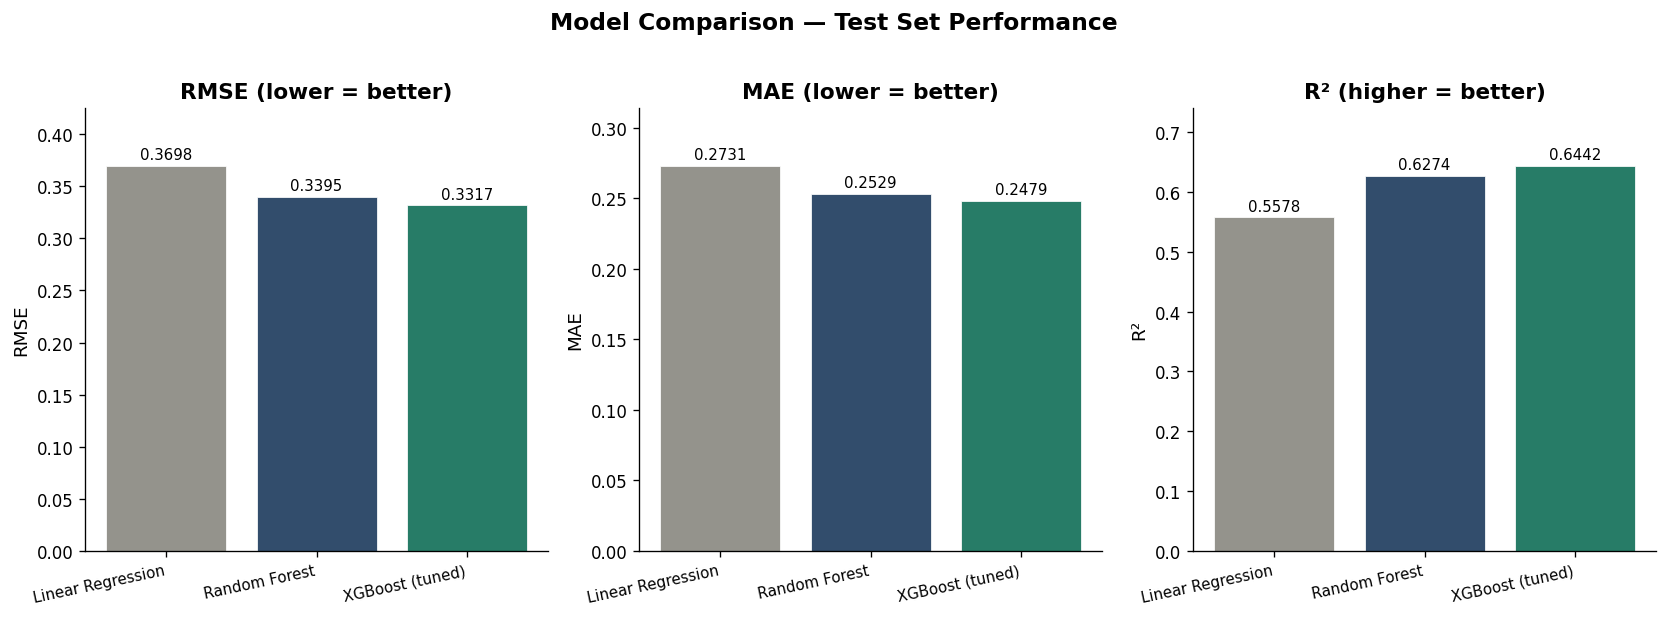

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models    = results_df.index.tolist()
x_pos     = np.arange(len(models))
bar_colors = [GREY, NAVY, TEAL]
metrics   = ['RMSE', 'MAE', 'R²']
better    = ['lower', 'lower', 'higher']

for ax, metric, direction in zip(axes, metrics, better):
    vals = results_df[metric].values
    bars = ax.bar(x_pos, vals, color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.9)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + (vals.max() * 0.01),
            f'{val:.4f}', ha='center', va='bottom', fontsize=9
        )

    ax.set_title(f'{metric} ({direction} = better)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=12, ha='right', fontsize=9)
    ax.set_ylabel(metric)
    ax.set_ylim(0, vals.max() * 1.15)

plt.suptitle('Model Comparison — Test Set Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE}/models/plot_model_comparison.png', bbox_inches='tight')
plt.show()

---
## 7. Residual Analysis (XGBoost)

Residuals tell us where the model struggles — systematic patterns here would suggest missing features or modelling assumptions we've violated.

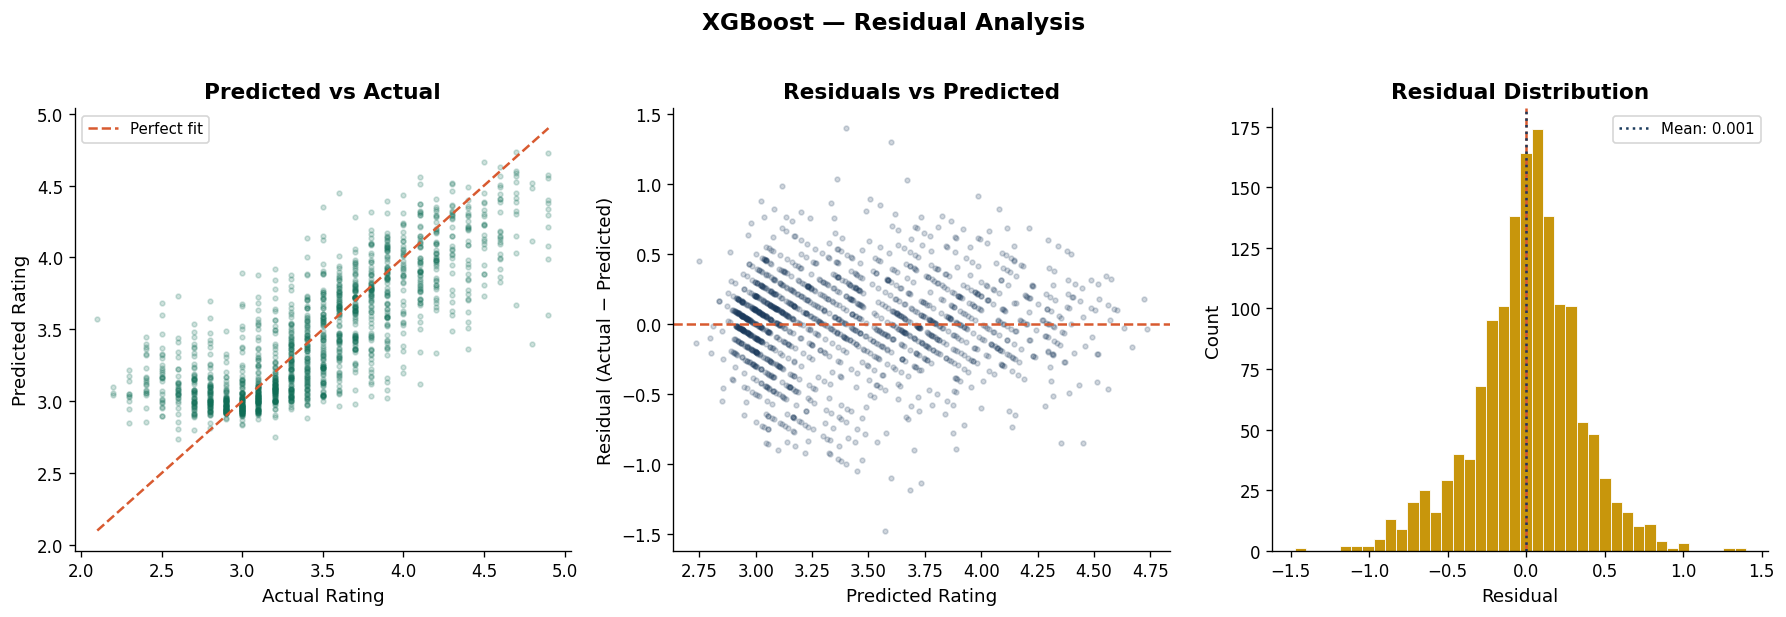

Residuals — Mean: 0.0010, Std: 0.3317


In [13]:
y_pred     = xgb_best.predict(X_test)
residuals  = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Predicted vs Actual ────────────────────────────────────────────────────
axes[0].scatter(y_test, y_pred, alpha=0.2, s=8, color=TEAL)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color=CORAL, lw=1.5, linestyle='--', label='Perfect fit')
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].legend(fontsize=9)

# ── Residuals vs Predicted ─────────────────────────────────────────────────
axes[1].scatter(y_pred, residuals, alpha=0.2, s=8, color=NAVY)
axes[1].axhline(0, color=CORAL, lw=1.5, linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Rating')
axes[1].set_ylabel('Residual (Actual − Predicted)')

# ── Residual distribution ──────────────────────────────────────────────────
axes[2].hist(residuals, bins=40, color=GOLD, edgecolor='white', linewidth=0.5)
axes[2].axvline(0, color=CORAL, lw=1.5, linestyle='--')
axes[2].axvline(residuals.mean(), color=NAVY, lw=1.5,
                linestyle=':', label=f'Mean: {residuals.mean():.3f}')
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)

plt.suptitle('XGBoost — Residual Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE}/models/plot_residuals.png', bbox_inches='tight')
plt.show()

print(f'Residuals — Mean: {residuals.mean():.4f}, Std: {residuals.std():.4f}')

---
## 8. SHAP Interpretability

SHAP (SHapley Additive exPlanations) answers: **why did this restaurant get this predicted rating?**  
It assigns each feature a contribution value for every single prediction — globally and locally.

In [15]:
# ── Compute SHAP values ────────────────────────────────────────────────────
# Using a sample of 1,500 from the test set for speed
sample_idx  = np.random.default_rng(42).choice(len(X_test), size=min(1500, len(X_test)), replace=False)
X_shap      = X_test.iloc[sample_idx].reset_index(drop=True)

# Convert boolean columns to integer (0 or 1) as SHAP expects numerical inputs
# This addresses TypeError: Cannot cast array data from dtype('O') to dtype('float64')
for col in X_shap.columns:
    if X_shap[col].dtype == 'bool':
        X_shap[col] = X_shap[col].astype(int)

explainer   = shap.Explainer(xgb_best, X_shap)
shap_values = explainer(X_shap)

print(f'SHAP values computed for {len(X_shap):,} samples.')
print(f'Shape: {shap_values.values.shape}')

SHAP values computed for 1,481 samples.
Shape: (1481, 27)


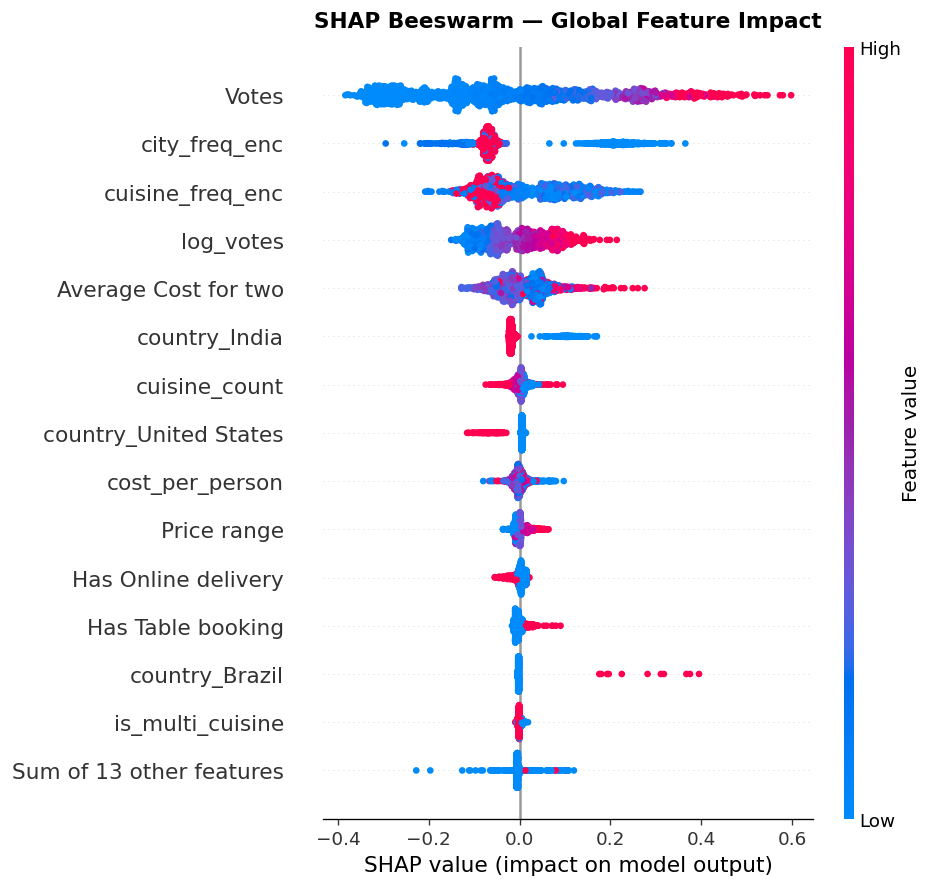

In [16]:
# ── 8a. Beeswarm — Global feature importance with direction ───────────────
# Each dot is one restaurant. Position on x-axis = SHAP value (impact on prediction).
# Colour = feature value (red = high, blue = low).
# Width of the swarm shows how often that impact occurs.

plt.figure(figsize=(11, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Beeswarm — Global Feature Impact', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{BASE}/models/plot_shap_beeswarm.png', bbox_inches='tight')
plt.show()

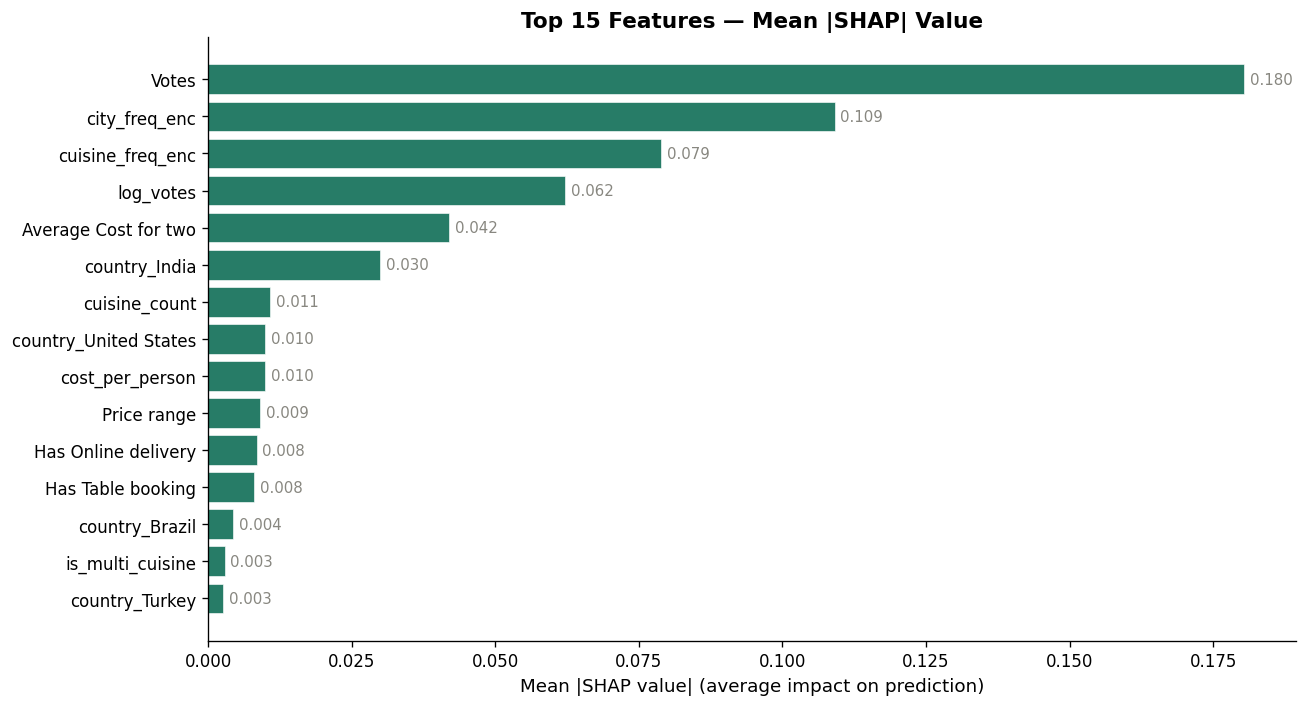

Top 5 most impactful features:
Votes                   0.180404
city_freq_enc           0.109078
cuisine_freq_enc        0.078893
log_votes               0.062121
Average Cost for two    0.041993
dtype: float64


In [17]:
# ── 8b. Bar chart — Mean absolute SHAP (clean ranking) ───────────────────
mean_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=feature_columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    mean_shap.index[::-1], mean_shap.values[::-1],
    color=TEAL, edgecolor='white', linewidth=0.4, alpha=0.9
)
for bar, val in zip(bars, mean_shap.values[::-1]):
    ax.text(
        bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
        f'{val:.3f}', va='center', ha='left', fontsize=9, color=GREY
    )
ax.set_title('Top 15 Features — Mean |SHAP| Value', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP value| (average impact on prediction)')
plt.tight_layout()
plt.savefig(f'{BASE}/models/plot_shap_bar.png', bbox_inches='tight')
plt.show()

print('Top 5 most impactful features:')
print(mean_shap.head())

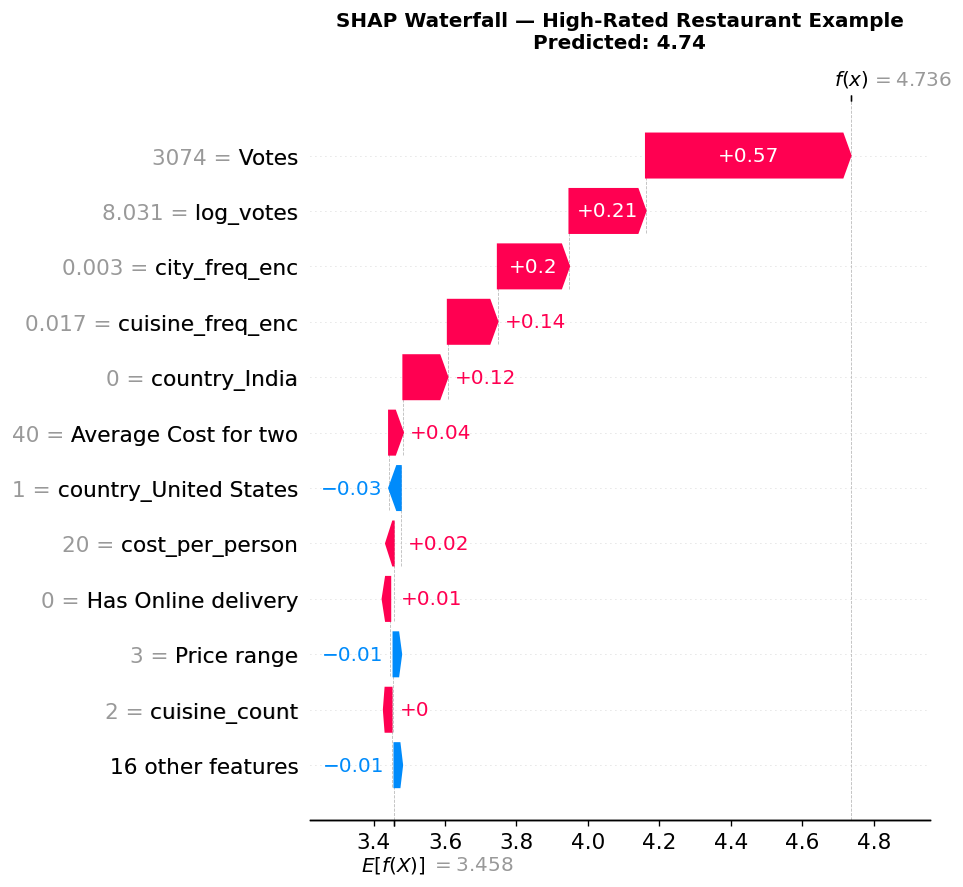

In [18]:
# ── 8c. Waterfall — One restaurant explained ─────────────────────────────
# Pick one test restaurant and show exactly which features pushed its
# predicted rating up or down from the baseline.

# Find an interesting example: a restaurant with a high predicted rating
high_pred_idx = np.argmax(xgb_best.predict(X_shap))

plt.figure(figsize=(11, 7))
shap.plots.waterfall(shap_values[high_pred_idx], max_display=12, show=False)
plt.title(
    f'SHAP Waterfall — High-Rated Restaurant Example\n'
    f'Predicted: {xgb_best.predict(X_shap)[high_pred_idx]:.2f}',
    fontsize=12, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig(f'{BASE}/models/plot_shap_waterfall_high.png', bbox_inches='tight')
plt.show()

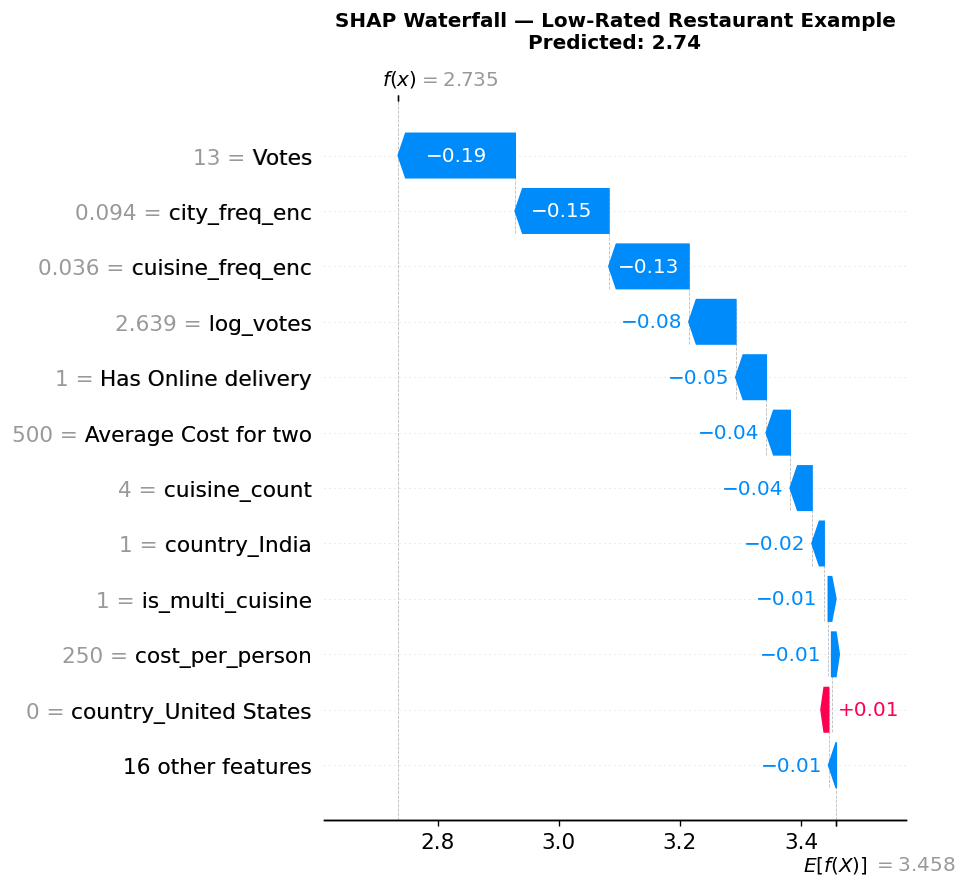

In [19]:
# ── 8d. Waterfall — A low-rated restaurant for contrast ──────────────────
low_pred_idx = np.argmin(xgb_best.predict(X_shap))

plt.figure(figsize=(11, 7))
shap.plots.waterfall(shap_values[low_pred_idx], max_display=12, show=False)
plt.title(
    f'SHAP Waterfall — Low-Rated Restaurant Example\n'
    f'Predicted: {xgb_best.predict(X_shap)[low_pred_idx]:.2f}',
    fontsize=12, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig(f'{BASE}/models/plot_shap_waterfall_low.png', bbox_inches='tight')
plt.show()

<Figure size 1200x720 with 0 Axes>

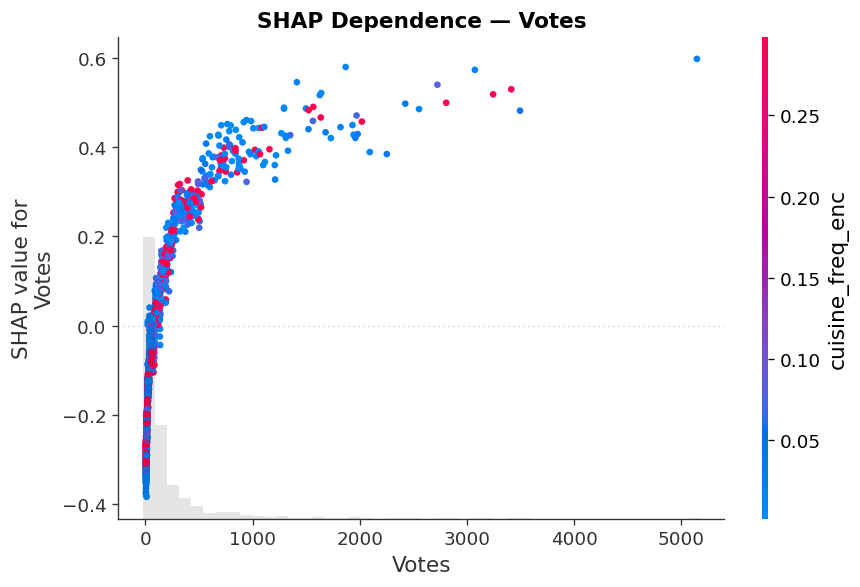

In [20]:
# ── 8e. Dependence plot — log_votes (likely top feature) ─────────────────
# Shows how a single feature's value relates to its SHAP impact.
# The colour dimension shows interaction with a second feature (auto-selected).

top_feature = mean_shap.index[0]  # whatever ranked #1

plt.figure(figsize=(10, 6))
shap.plots.scatter(shap_values[:, top_feature], color=shap_values, show=False)
plt.title(f'SHAP Dependence — {top_feature}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE}/models/plot_shap_dependence.png', bbox_inches='tight')
plt.show()

---
## 9. Save Model & Feature Columns

In [21]:
import os
os.makedirs(MODELS, exist_ok=True)

# Save the trained XGBoost model
with open(f'{MODELS}/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_best, f)

# Save the feature column list — Streamlit needs exact same columns in same order
with open(f'{MODELS}/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

# Save best params for reference
with open(f'{MODELS}/best_params.pkl', 'wb') as f:
    pickle.dump(search.best_params_, f)

print('Saved:')
print(f'  {MODELS}/xgb_model.pkl')
print(f'  {MODELS}/feature_columns.pkl')
print(f'  {MODELS}/best_params.pkl')

Saved:
  /content/drive/MyDrive/Colab Notebooks/zomato-rating-predictor/models/xgb_model.pkl
  /content/drive/MyDrive/Colab Notebooks/zomato-rating-predictor/models/feature_columns.pkl
  /content/drive/MyDrive/Colab Notebooks/zomato-rating-predictor/models/best_params.pkl


---
## 10. Final Summary

In [22]:
print('=' * 60)
print('NOTEBOOK 3 — FINAL SUMMARY')
print('=' * 60)
print()
print('MODEL RESULTS (test set):')
print(results_df.to_string())
print()
print('BEST MODEL: XGBoost (tuned)')
print(f'  RMSE: {results_df.loc["XGBoost (tuned)", "RMSE"]:.4f}')
print(f'  MAE:  {results_df.loc["XGBoost (tuned)", "MAE"]:.4f}')
print(f'  R²:   {results_df.loc["XGBoost (tuned)", "R²"]:.4f}')
print()
print('TOP 5 FEATURES BY SHAP IMPORTANCE:')
for i, (feat, val) in enumerate(mean_shap.head().items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')
print()
print('FILES SAVED:')
print(f'  xgb_model.pkl, feature_columns.pkl, best_params.pkl')
print()
print('=== NOTEBOOK 3 COMPLETE ===')
print('Next: Build the Streamlit app using xgb_model.pkl')

NOTEBOOK 3 — FINAL SUMMARY

MODEL RESULTS (test set):
                     RMSE     MAE      R²  CV RMSE
Model                                             
Linear Regression  0.3698  0.2731  0.5578   0.3804
Random Forest      0.3395  0.2529  0.6274   0.3562
XGBoost (tuned)    0.3317  0.2479  0.6442   0.3491

BEST MODEL: XGBoost (tuned)
  RMSE: 0.3317
  MAE:  0.2479
  R²:   0.6442

TOP 5 FEATURES BY SHAP IMPORTANCE:
  1. Votes: 0.1804
  2. city_freq_enc: 0.1091
  3. cuisine_freq_enc: 0.0789
  4. log_votes: 0.0621
  5. Average Cost for two: 0.0420

FILES SAVED:
  xgb_model.pkl, feature_columns.pkl, best_params.pkl

=== NOTEBOOK 3 COMPLETE ===
Next: Build the Streamlit app using xgb_model.pkl
